## Introduction

This project investigates credit card fraud detection using the Kaggle “Credit Card Fraud Detection” dataset. With only ~0.17% of transactions labeled as fraud, the core challenge is extreme class imbalance and the high cost of missing fraudulent events. We compare cost-aware supervised classifiers (especially a class-weighted Random Forest) with anomaly detection methods (One-Class SVM and an Autoencoder) to understand which approaches work best and
whether anomaly detectors add value beyond a strong supervised baseline.

For this project, we have three Research Questions (RQs), as indicated provided below. Each of the RQs are summarized and answered in Section 7 of this notebook

- **RQ1 (Supervised Classification):**
How do different supervised classifiers (Logistic Regression, Decision Tree, Random Forest) trade off precision, recall, and cost-sensitive performance for fraud detection under varying decision thresholds?

- **RQ2 (Clustering):**
Do fraud and non-fraud transactions exhibit distinct cluster structures in the PCA feature space, and can clustering help identify subtypes of fraudulent transactions?

- **RQ3 (One-Class SVM vs Autoencoder vs Supervised Classifier):**
How do kernel-based (One-Class SVM) and neural (autoencoder) anomaly detection methods compare in detecting fraudulent transactions, and do they flag complementary sets of frauds relative to a supervised classifier?


## 0. Import and Global Configuration

In [38]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
## Imports and global configuration

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Importing applicable AI/ML Libriaries and functions
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.ensemble import IsolationForest

RANDOM_STATE = 42  # For reproducibility
np.random.seed(RANDOM_STATE)

In [41]:
import platform
print(platform.python_version())

3.12.13


## 1. Data Loading and Basic EDA

### 1.1 Data Loading

In [19]:
## Load dataset

# Update the data_path location as needed to ensure that this file (main_notebook.ipynb) is in the same directory as the creditcard.csv file
data_path = '/content/drive/MyDrive/CSCE676/Project/creditcard.csv'

df = pd.read_csv(data_path)

print("Shape:", df.shape)
print(df.head())

Shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26 

### 1.2 Data Info and Missing Value Check

Check the information and any missing values for the dataset

In [20]:
## Quick data info and missing value check
print("\nInfo:")
print(df.info())

print("\nMissing values per column:")
print(df.isna().sum())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21

As observed above, all the features (i.e. columns) do not have any missing values, so imputation or extrapolation is required.

### 1.3 Class Distribution

Checking the distribution of the dataset, to observe any imbalance behaviors or not.

Class counts:
 Class
0    284315
1       492
Name: count, dtype: int64

Class ratio:
 Class
0    0.998273
1    0.001727
Name: count, dtype: float64


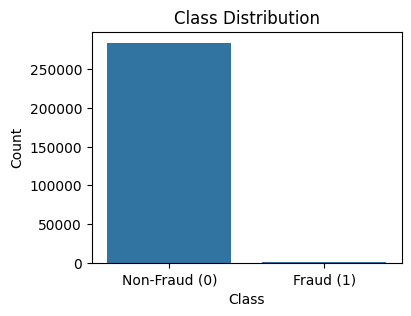

In [21]:
## Class distribution

class_counts = df['Class'].value_counts()
class_ratio = class_counts / len(df)

print("Class counts:\n", class_counts)
print("\nClass ratio:\n", class_ratio)

plt.figure(figsize=(4,3))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.xticks([0,1], ['Non-Fraud (0)', 'Fraud (1)'])
plt.title('Class Distribution')
plt.ylabel('Count')
plt.show()

As seen above, the data is VERY imbalanced. ~0.17% of the data is categorized as fraud.

### 1.4 Basic Distribution of Amount and Time by class

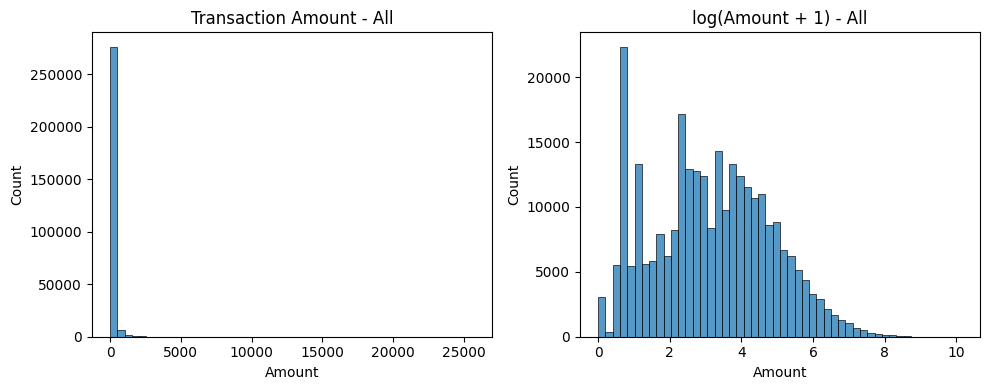

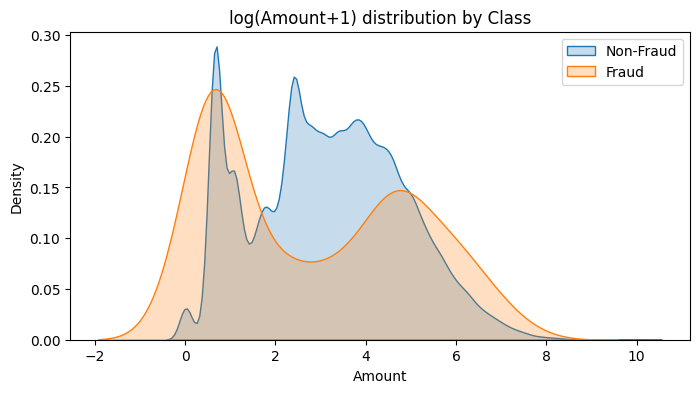

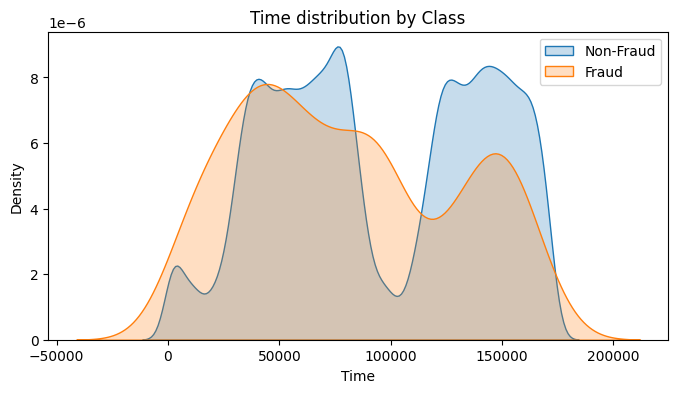

In [22]:
## Basic distributions of Amount and Time by class

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df['Amount'], bins=50, kde=False)
plt.title('Transaction Amount - All')

plt.subplot(1,2,2)
sns.histplot(np.log1p(df['Amount']), bins=50, kde=False)
plt.title('log(Amount + 1) - All')
plt.tight_layout()
plt.show()

# Compare Amount distribution by class (log scale for readability)
plt.figure(figsize=(8,4))
sns.kdeplot(np.log1p(df.loc[df['Class']==0, 'Amount']), label='Non-Fraud', fill=True)
sns.kdeplot(np.log1p(df.loc[df['Class']==1, 'Amount']), label='Fraud', fill=True)
plt.title('log(Amount+1) distribution by Class')
plt.legend()
plt.show()

# Time distribution by class
plt.figure(figsize=(8,4))
sns.kdeplot(df.loc[df['Class']==0, 'Time'], label='Non-Fraud', fill=True)
sns.kdeplot(df.loc[df['Class']==1, 'Time'], label='Fraud', fill=True)
plt.title('Time distribution by Class')
plt.legend()
plt.show()

## 2. Train/Validation/Test Split and Preprocessing

### 2.1 Feature/Label Split

Generating two features on teh dataset provided and labeling it

In [23]:
## Feature/label split

X = df.drop(columns=['Class'])
y = df['Class']

### 2.2 Train/Validation/Test data split

Performing a 60/20/20 Train/Validation (Val)/Test Split of the dataset, to ensure all the models will have decent generalization capaiblity to unseen data.

Training dataset will allow the models to learn patterns, adjust weights, and optimize parameters -> 60%

Validation dataset will be used for hyperparameter tuning and comparing different model architectures. It will provide unbiased evaulation during training to help select the best configuration -> 20%

Test dataset will be the holdout set used only once for final evalution against the trained model. It provides an unbiased estimate of real-world performance -> 20%



In [24]:
## Train/Validation (val)/Test split

# First split into train+val and test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Then split train+val into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE
)
# Train 60%, val 20%, test 20%

print("Train size:", X_train.shape[0], "Fraud rate:", y_train.mean())
print("Val size:", X_val.shape[0], "Fraud rate:", y_val.mean())
print("Test size:", X_test.shape[0], "Fraud rate:", y_test.mean())

Train size: 170883 Fraud rate: 0.0017263273701889597
Val size: 56962 Fraud rate: 0.0017380007724447878
Test size: 56962 Fraud rate: 0.0017204452090867595


### 2.3 Standardization/Scaling

Some models (logistic regression, k-means) are sensitive to scale.

Tree-based models (DecisionTree, RandomForest) are less sensitive, but we can still feed scaled inputs for consistency.

In [25]:
## Standardization
# Include Time, Amount, V1–V28

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

## 3. Supervised Classification & Threshold/Cost Analysis

For this section we will perform the following steps (as part of RQ1):
- Data Input (creditcard.csv) -> Already done in Section 1
- Split Data (Train/Validation/Test) -> Already done in Section 2
- Scale Features -> Already done in Section 2
- Train Baseline Supervised Classifiers (Logistics Regression, Decision Tree, Random Forest) (in this section)
- Validate & Threshold Tuning (in this section)
- Selection of Supervised Classifer based on Evaluated Metrics and Test Results (in this section)


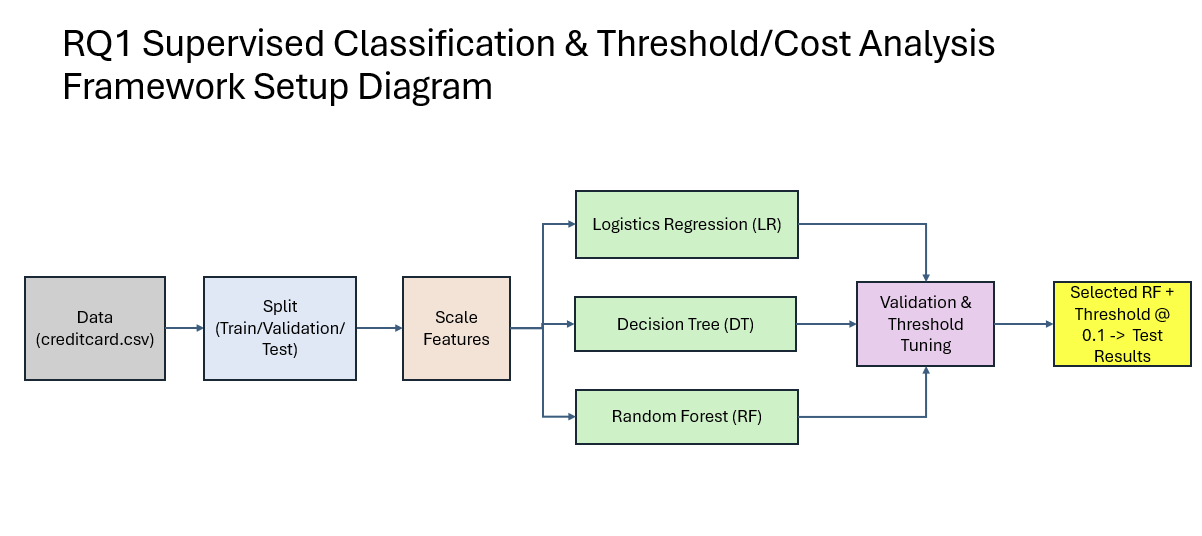

### 3.1 *Helper Function* for Evaluation and Threshold Analysis

In [47]:
def evaluate_classifier(model_name, y_true, y_proba, thresholds=None,
                        cost_fn=10.0, cost_fp=1.0):
    ##
    #Evaluate a binary classifier using ROC-AUC, PR-AUC, and threshold-based metrics.
    #- model_name: string for printing
    #- y_true: ground truth labels
    #- y_proba: predicted probability for positive class
    #- thresholds: list of thresholds to evaluate; if None, use [0.5]
    #- cost_fn: cost of false negative (missed fraud)
    #- cost_fp: cost of false positive (false alarm)
    ##
    if thresholds is None:
        thresholds = [0.5]

    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc  = average_precision_score(y_true, y_proba)

    print(f"=== {model_name} ===")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC : {pr_auc:.4f}")

    results = []

    for thr in thresholds:
        y_pred = (y_proba >= thr).astype(int)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall    = recall_score(y_true, y_pred, zero_division=0)
        f1        = f1_score(y_true, y_pred, zero_division=0)

        # Cost-sensitive expected cost per sample:
        # FN: y_true=1 but y_pred=0
        # FP: y_true=0 but y_pred=1
        fn = np.sum((y_true==1) & (y_pred==0))
        fp = np.sum((y_true==0) & (y_pred==1))
        n  = len(y_true)
        cost = (cost_fn * fn + cost_fp * fp) / n

        results.append({
            'threshold': thr,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'cost': cost
        })

    results_df = pd.DataFrame(results)
    print("\nThreshold-based metrics:")
    display(results_df)

    return roc_auc, pr_auc, results_df

### 3.2 Train Baseline Supervised Classifiers

For the Supervised Classifiers, the following three are chosen:

1. **Logistic Regression**
  - `class_weight='balanced'`: to handle imbalance  
2. **Decision Tree**
  - `class_weight='balanced'`: to handle imbalance
  - max depth = 8: to liimt depth to reduce overfitting
3. **Random Forest**
  - `class_weight='balanced'`: to handle imbalance
  - n_estimators = 100: to balance performance/runtime



In [27]:
## Train baseline supvervised classifiers

# Logistic Regression
log_reg = LogisticRegression(
    class_weight='balanced',  # handle imbalance
    max_iter=1000,
    random_state=RANDOM_STATE
)
log_reg.fit(X_train_scaled, y_train)

# Decision Tree
dt = DecisionTreeClassifier(
    class_weight='balanced',  # handle imbalance
    max_depth=8,              # limit depth to reduce overfitting
    random_state=RANDOM_STATE
)
dt.fit(X_train_scaled, y_train)

# Random Forest
rf = RandomForestClassifier(
    class_weight='balanced',  # handle imbalance
    n_estimators=100,         # balance performance/runtime
    max_depth=None,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

### 3.3 Evaluation on Validation Set

In [49]:
## Evaluate on validation set (for threshold and model selection)

thresholds_to_try = [0.05, 0.1, 0.2, 0.3, 0.5]

# Logistic Regression
val_proba_log = log_reg.predict_proba(X_val_scaled)[:,1]
evaluate_classifier(
    "Logistic Regression (val)",
    y_val, val_proba_log, thresholds=thresholds_to_try,
    cost_fn=10.0, cost_fp=1.0  # Example cost matrix: FN 10x FP
)

# Decision Tree
val_proba_dt = dt.predict_proba(X_val_scaled)[:,1]
evaluate_classifier(
    "Decision Tree (val)",
    y_val, val_proba_dt, thresholds=thresholds_to_try,
    cost_fn=10.0, cost_fp=1.0
)

# Random Forest
val_proba_rf = rf.predict_proba(X_val_scaled)[:,1]
evaluate_classifier(
    "Random Forest (val)",
    y_val, val_proba_rf, thresholds=thresholds_to_try,
    cost_fn=10.0, cost_fp=1.0
)

=== Logistic Regression (val) ===
ROC-AUC: 0.9747
PR-AUC : 0.6807

Threshold-based metrics:


,threshold,precision,recall,f1,cost
0,0.05,0.006258,0.989899,0.012437,0.273393
1,0.10,0.010092,0.939394,0.019970,0.161195
2,0.20,0.019177,0.909091,0.037563,0.082388
3,0.30,0.030633,0.909091,0.059269,0.051578
4,0.50,0.059651,0.898990,0.111879,0.026386


=== Decision Tree (val) ===
ROC-AUC: 0.8751
PR-AUC : 0.6012

Threshold-based metrics:


,threshold,precision,recall,f1,cost
0,0.05,0.138739,0.777778,0.235474,0.012254
1,0.10,0.138739,0.777778,0.235474,0.012254
2,0.20,0.138739,0.777778,0.235474,0.012254
3,0.30,0.138739,0.777778,0.235474,0.012254
4,0.50,0.138739,0.777778,0.235474,0.012254


=== Random Forest (val) ===
ROC-AUC: 0.9378
PR-AUC : 0.8003

Threshold-based metrics:


,threshold,precision,recall,f1,cost
0,0.05,0.669421,0.818182,0.736364,0.003862
1,0.10,0.814433,0.797980,0.806122,0.003827
2,0.20,0.853933,0.767677,0.808511,0.004266
3,0.30,0.903614,0.757576,0.824176,0.004354
4,0.50,0.958904,0.707071,0.813953,0.005144


(np.float64(0.937777880807619),
 np.float64(0.800292951246588),
    threshold  precision    recall        f1      cost
 0       0.05   0.669421  0.818182  0.736364  0.003862
 1       0.10   0.814433  0.797980  0.806122  0.003827
 2       0.20   0.853933  0.767677  0.808511  0.004266
 3       0.30   0.903614  0.757576  0.824176  0.004354
 4       0.50   0.958904  0.707071  0.813953  0.005144)

As shown above, the Random Forest (which is also class weighted) has the best PR-AUC (0.8003), compared to decision tree (0.6012) and logistic regression (0.6807).

Thus, **Class-Weighted Random Forest** is the best supervised classifier based on primarily on PR-AUC, due to PR-AUC is a better metric for highly imbalanced data.

### 3.4 Supervised Classifier Receiver Operating Curve (ROC) and Precision Recall (PR) Curves

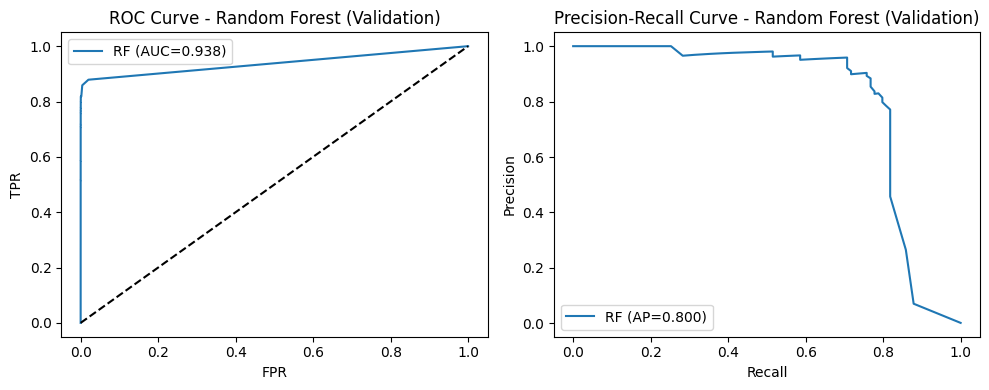

In [53]:
## Plot ROC and PR curves for one Class Weighted Random Forest on validation set

fpr, tpr, _ = roc_curve(y_val, val_proba_rf)
prec, rec, _ = precision_recall_curve(y_val, val_proba_rf)
roc_auc_val = roc_auc_score(y_val, val_proba_rf)
pr_auc_val = average_precision_score(y_val, val_proba_rf)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f'RF (AUC={roc_auc_val:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve - Random Forest (Validation)')
plt.legend()

plt.subplot(1,2,2)
plt.plot(rec, prec, label=f'RF (AP={pr_auc_val:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Random Forest (Validation)')
plt.legend()

plt.tight_layout()
plt.show()

### 3.5 Supervised Classifier: Final Evaluation on Test Set

In [63]:
## Final evaluation on test set using Random Forest and threshold

best_model = rf
best_threshold = 0.1     # Chosen from validation threshold table

test_proba = best_model.predict_proba(X_test_scaled)[:,1]
evaluate_classifier(
    f"Random Forest (test, thr={best_threshold})",
    y_test, test_proba, thresholds=[best_threshold],
    cost_fn=10.0, cost_fp=1.0
)

=== Random Forest (test, thr=0.1) ===
ROC-AUC: 0.9529
PR-AUC : 0.8454

Threshold-based metrics:


,threshold,precision,recall,f1,cost
0,0.1,0.770642,0.857143,0.811594,0.002897


(np.float64(0.9529224939131533),
 np.float64(0.8454116624715653),
    threshold  precision    recall        f1      cost
 0        0.1   0.770642  0.857143  0.811594  0.002897)

## 4. Fraud Data Clustering and Structure

For this section we will perform the following steps (as part of RQ2):
- Subsample (in this section)
- Scale features (in this section)
- K-Means Clustering (in this section)
- Compute Internal Metrics (Silhouette, Davies-Bouldin) (in this section)
- Assign Clusters (in this section)
- Analyze Fraud Rate per Cluster + PCA Scatterplots (in this section)


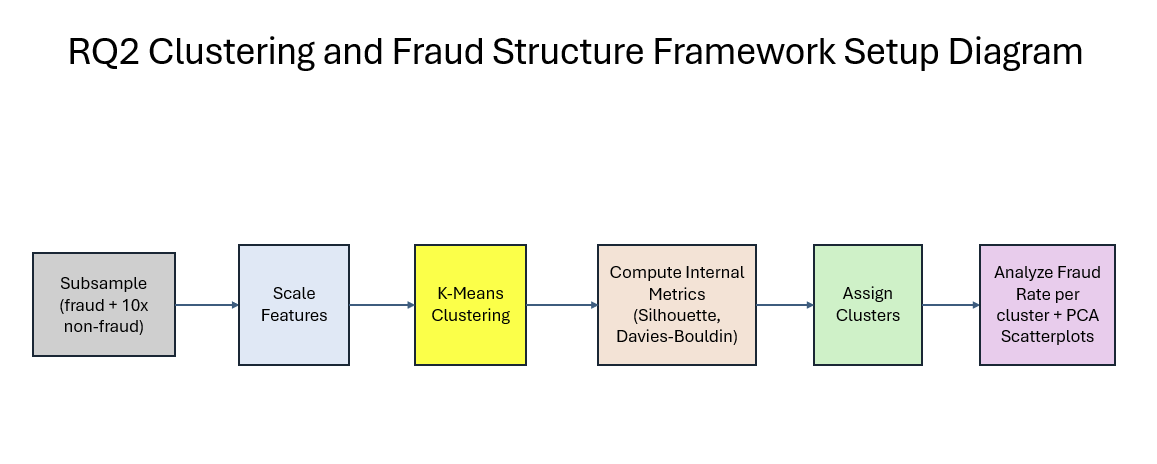

### 4.1 Subsample creation

In [71]:
## Create a subsample: all frauds + subset of non-frauds

fraud_idx = df[df['Class']==1].index
nonfraud_idx = df[df['Class']==0].index

# Set ratio of 10:1 for non-fraud to fraud
nonfraud_sample_size = min(10 * len(fraud_idx), len(nonfraud_idx))

nonfraud_sample_idx = np.random.choice(nonfraud_idx, size=nonfraud_sample_size, replace=False)

subsample_idx = np.concatenate([fraud_idx, nonfraud_sample_idx])
subsample_df = df.loc[subsample_idx].sample(frac=1.0, random_state=RANDOM_STATE)  # shuffle

print("Subsample shape:", subsample_df.shape)
print("Fraud rate in subsample:", subsample_df['Class'].mean())

X_sub = subsample_df.drop(columns=['Class'])
y_sub = subsample_df['Class']

X_sub_scaled = scaler.fit_transform(X_sub)  # Re-fit scaler on subsample for clustering

Subsample shape: (5412, 31)
Fraud rate in subsample: 0.09090909090909091


### 4.2 K-Means with Internal Metrics

k=2: Silhouette=0.6716, Davies-Bouldin=0.9590
k=3: Silhouette=0.4562, Davies-Bouldin=1.3583
k=4: Silhouette=0.0859, Davies-Bouldin=2.3633
k=5: Silhouette=0.0893, Davies-Bouldin=1.9743
k=8: Silhouette=0.1019, Davies-Bouldin=1.7041
k=10: Silhouette=0.0969, Davies-Bouldin=1.6577


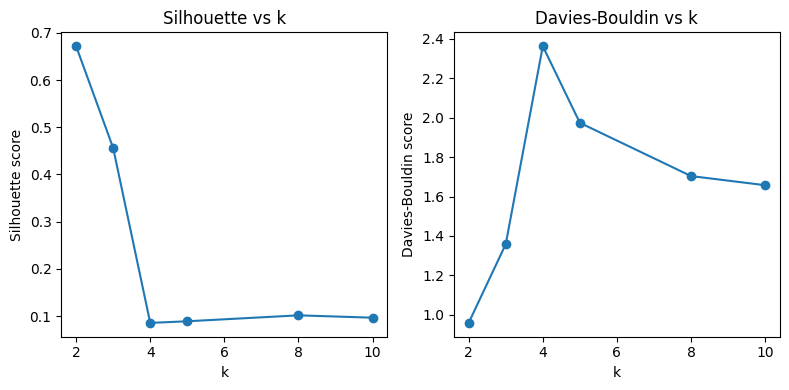

In [72]:
## Run k-means for multiple k and evaluate internal metrics

k_values = [2, 3, 4, 5, 8, 10]
sil_scores = []
db_scores  = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    labels = kmeans.fit_predict(X_sub_scaled)

    sil = silhouette_score(X_sub_scaled, labels)
    db  = davies_bouldin_score(X_sub_scaled, labels)

    sil_scores.append(sil)
    db_scores.append(db)

    print(f"k={k}: Silhouette={sil:.4f}, Davies-Bouldin={db:.4f}")

# Plotting scores vs k
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(k_values, sil_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.title('Silhouette vs k')

plt.subplot(1,2,2)
plt.plot(k_values, db_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Davies-Bouldin score')
plt.title('Davies-Bouldin vs k')

plt.tight_layout()
plt.show()

The best k value is 4 (k = 4), due to silhouette score being the lowest while the Davies-Bouldin score is at the peak.

In [73]:
chosen_k = 4
kmeans_chosen = KMeans(
    n_clusters=chosen_k,
    random_state=RANDOM_STATE,
    n_init=10
)
cluster_labels = kmeans_chosen.fit_predict(X_sub_scaled)
subsample_df['cluster'] = cluster_labels

cluster_summary = subsample_df.groupby('cluster')['Class'].agg(['count', 'mean'])
cluster_summary.rename(columns={'mean': 'fraud_rate'}, inplace=True)
display(cluster_summary)

,count,fraud_rate
cluster,,
0,274,1.000000
1,2444,0.020458
2,2587,0.023579
3,107,1.000000


Notes:
- Fraud rate per cluster vs global fraud rate in subsample provides insight into whether some clusters are enriched in fraudulent transactions.

### 4.3 Feature Distribution across Clusters

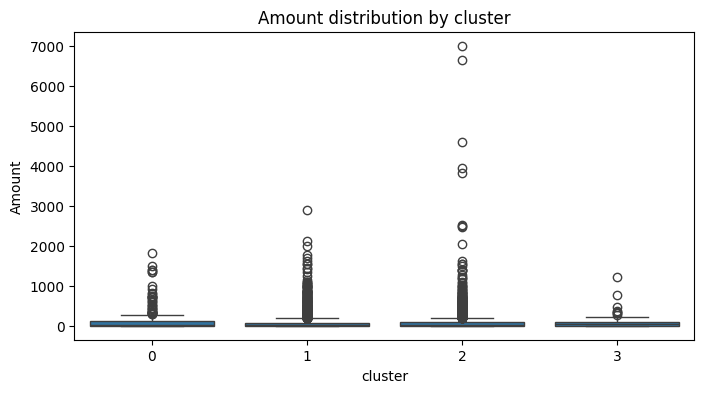

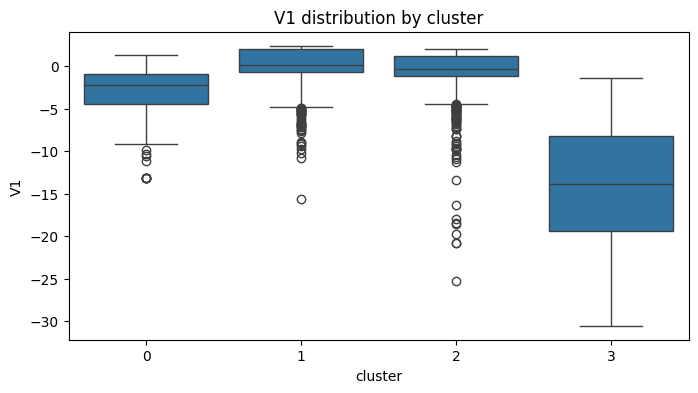

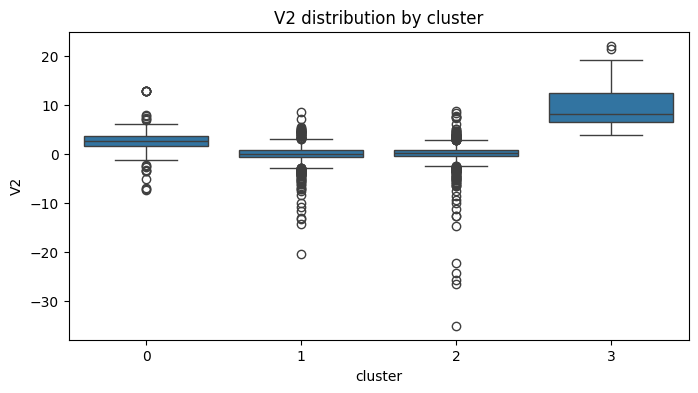

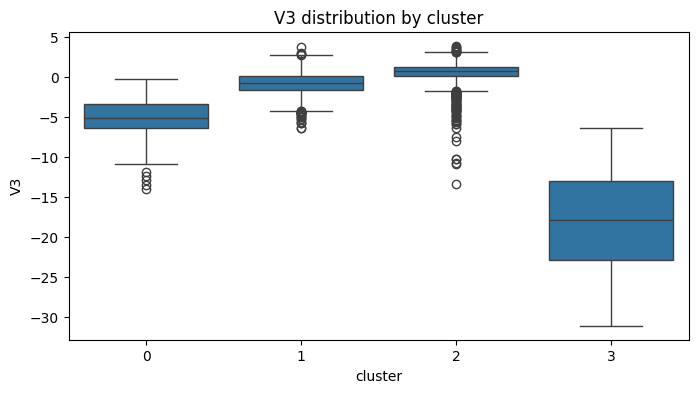

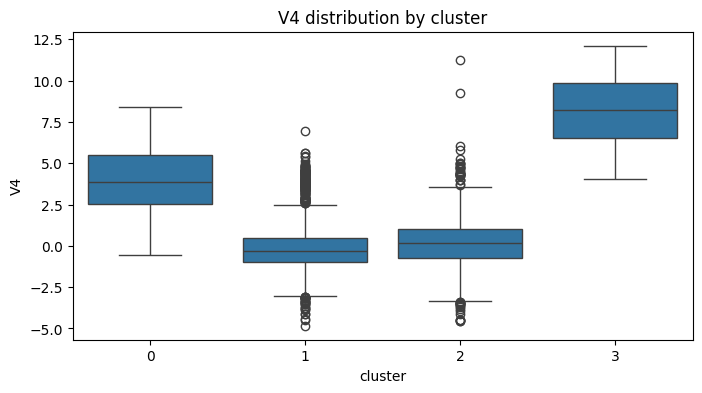

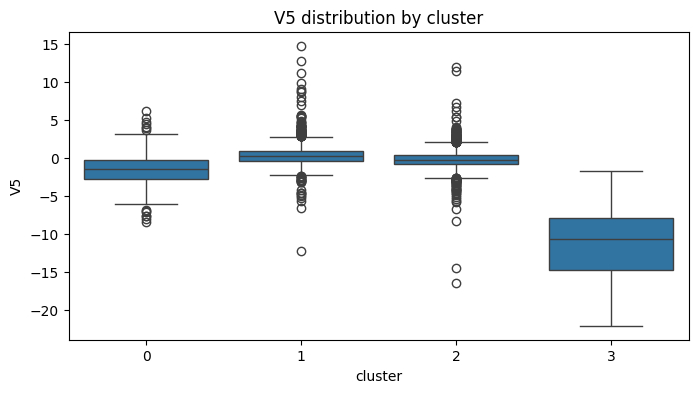

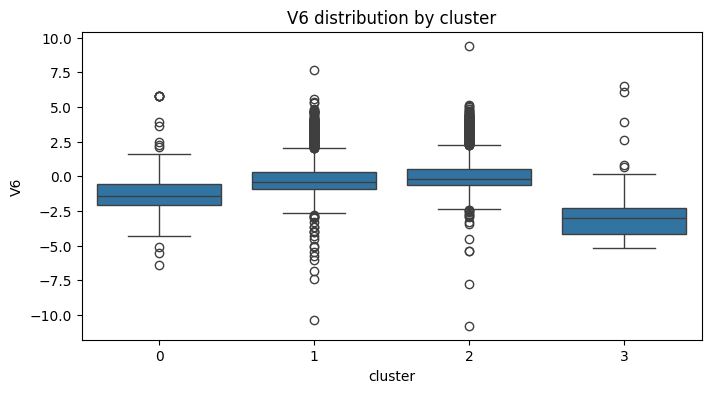

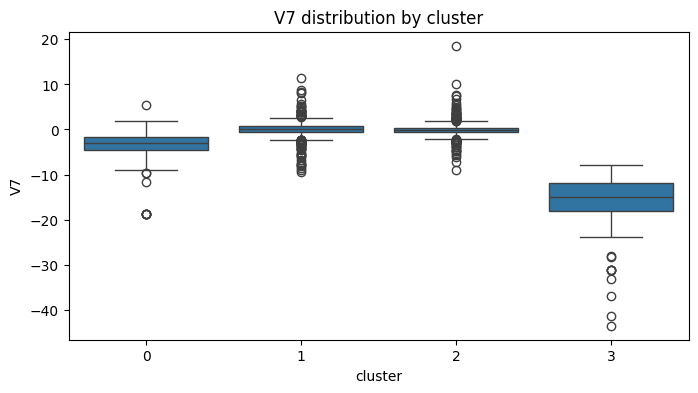

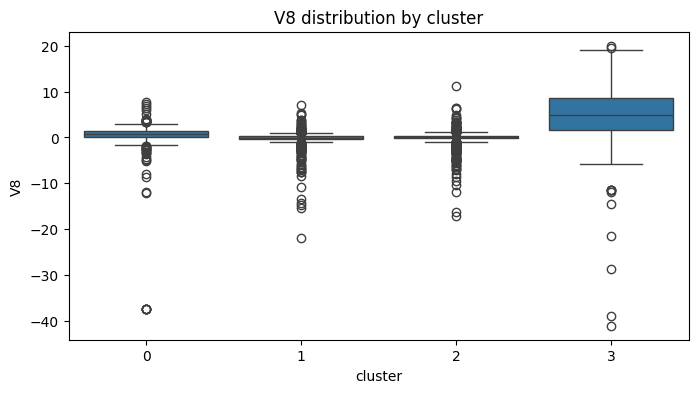

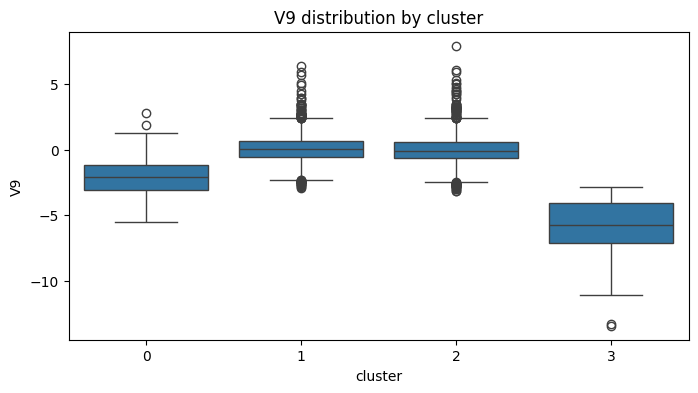

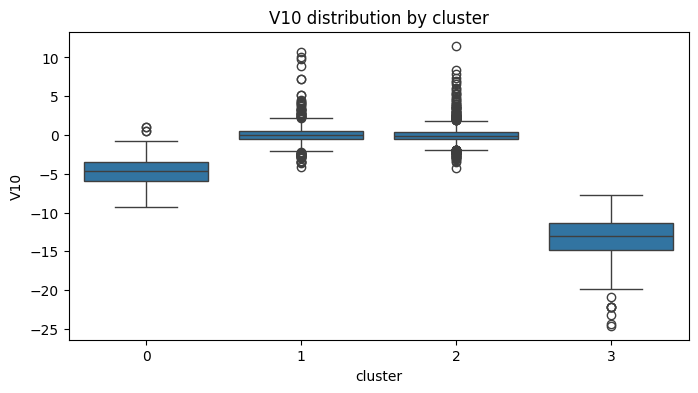

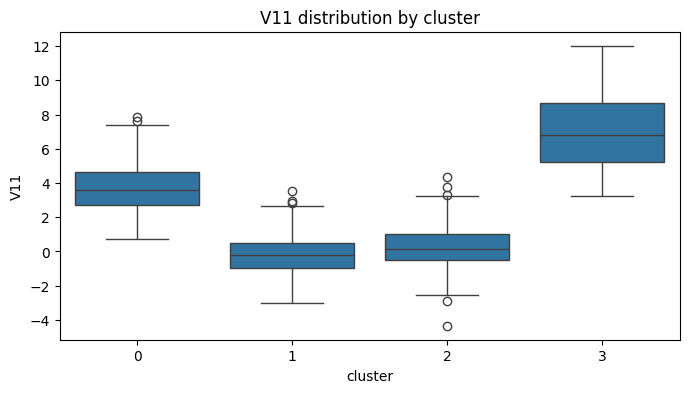

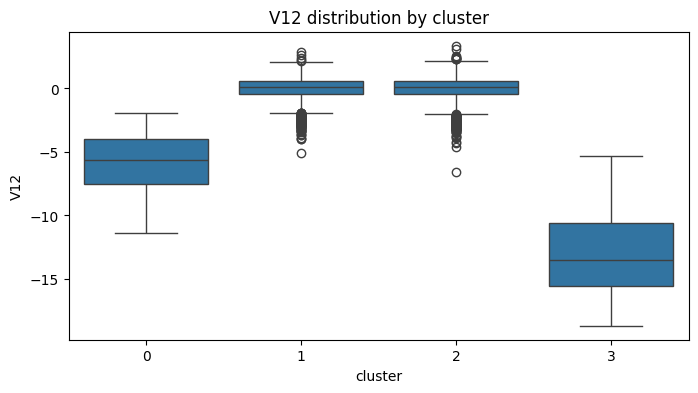

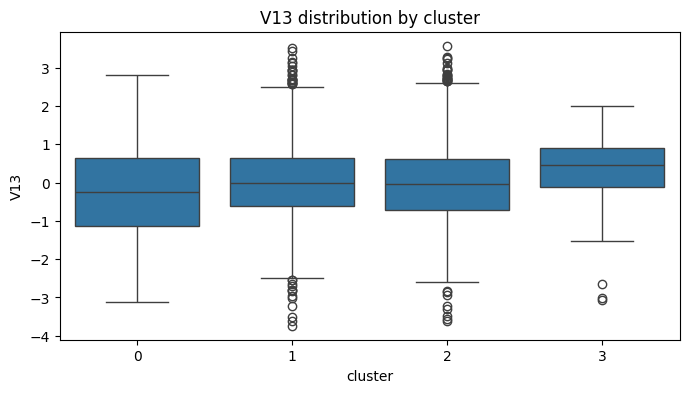

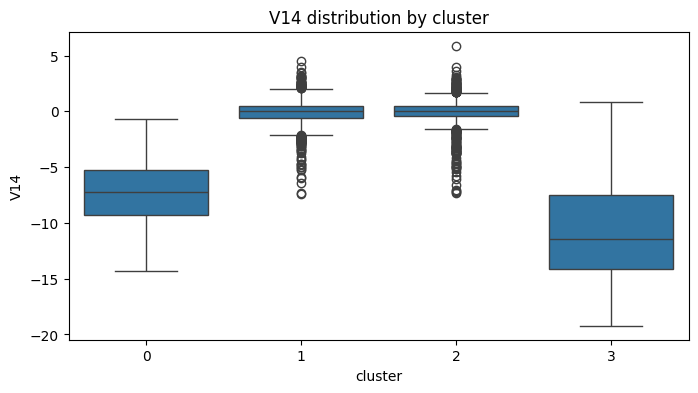

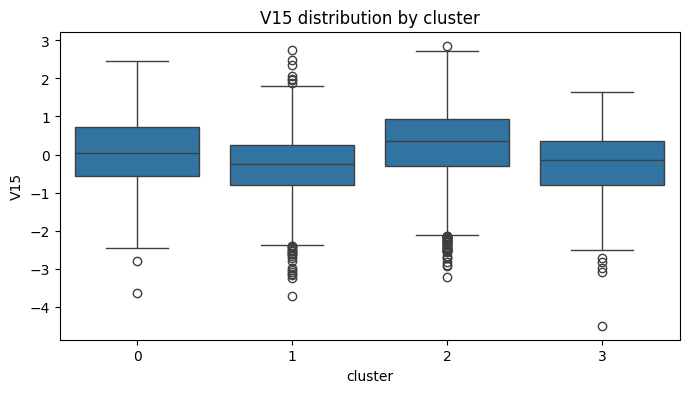

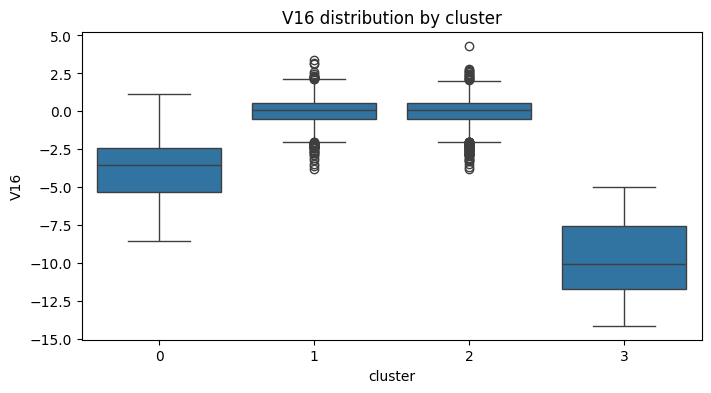

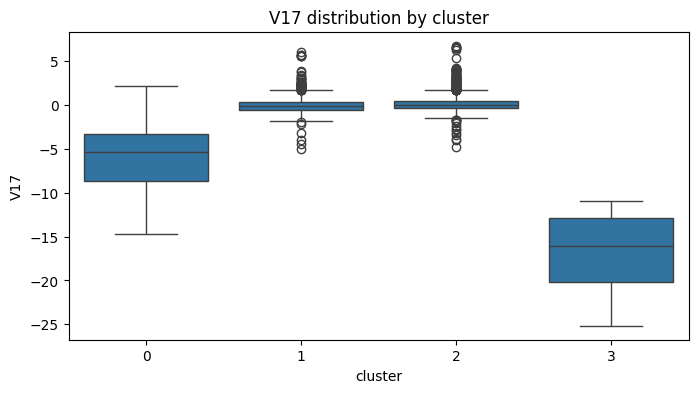

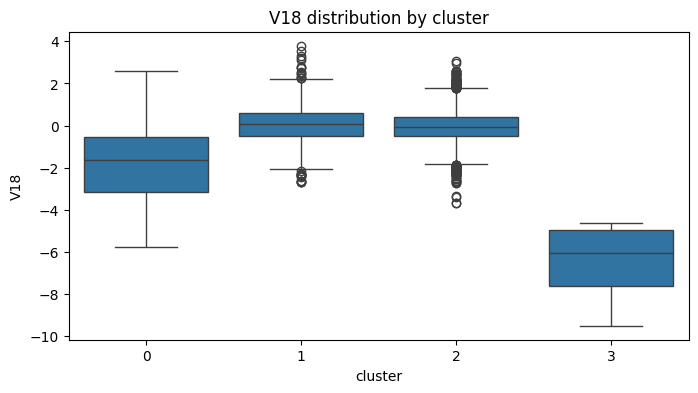

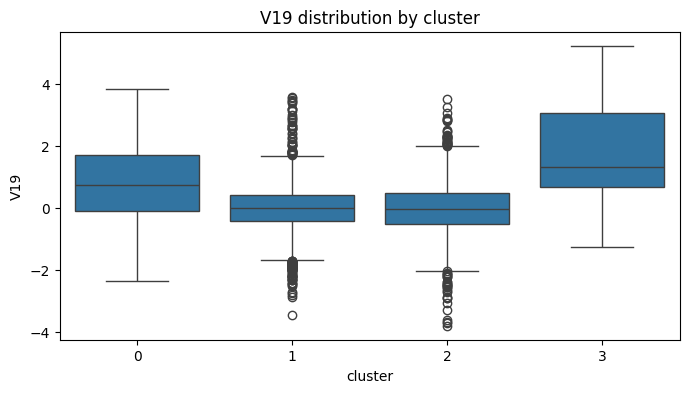

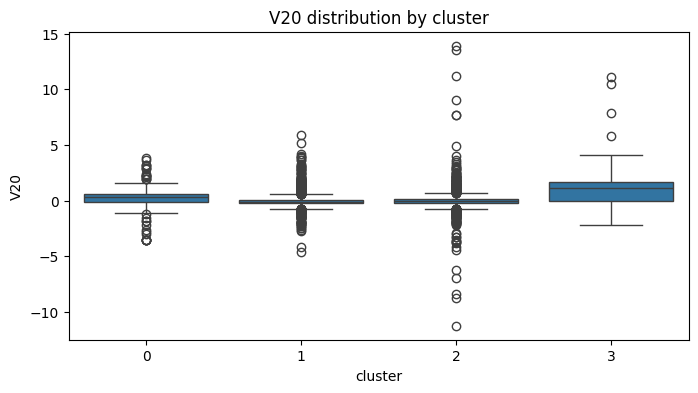

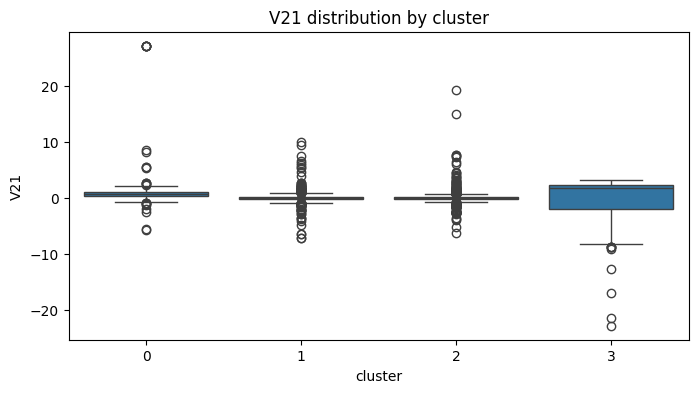

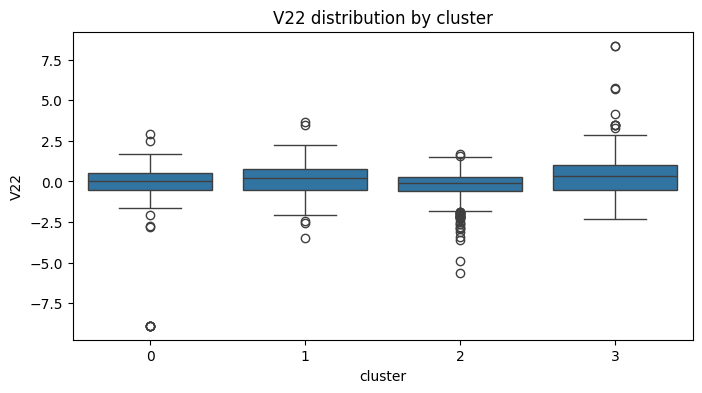

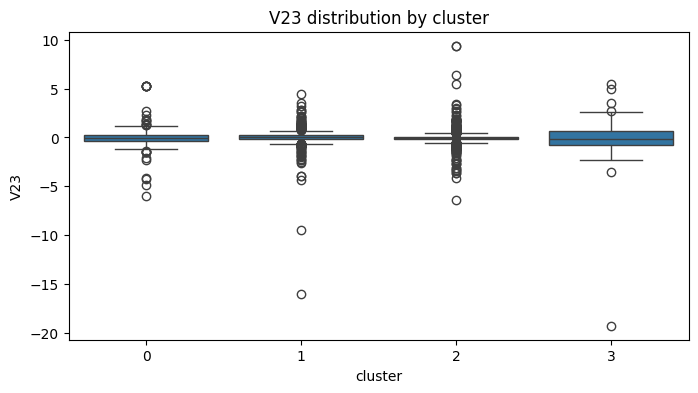

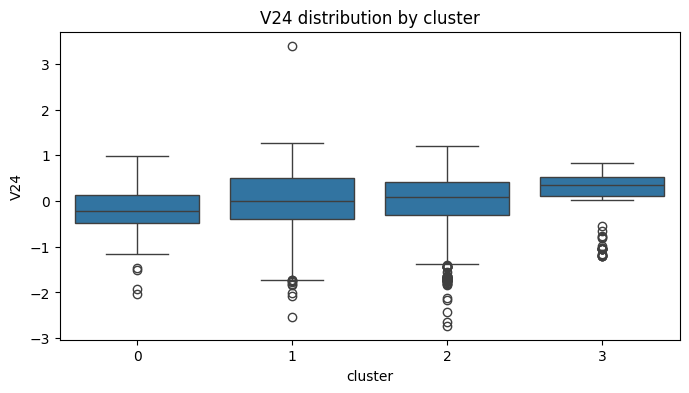

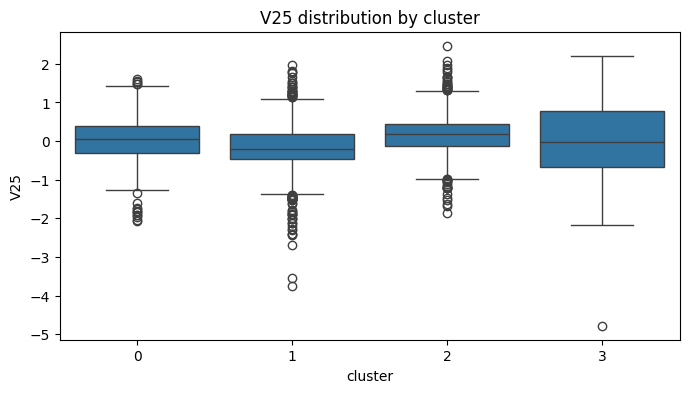

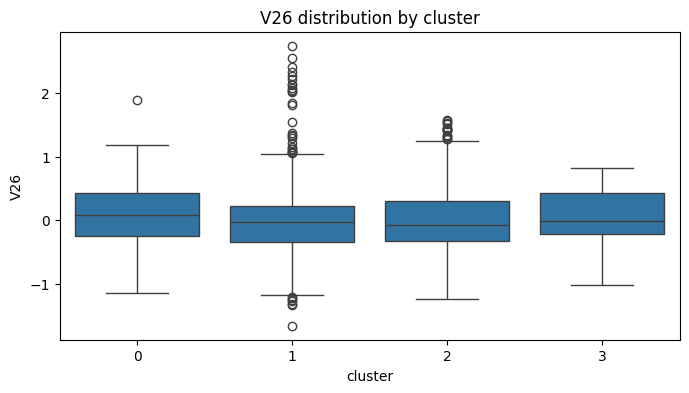

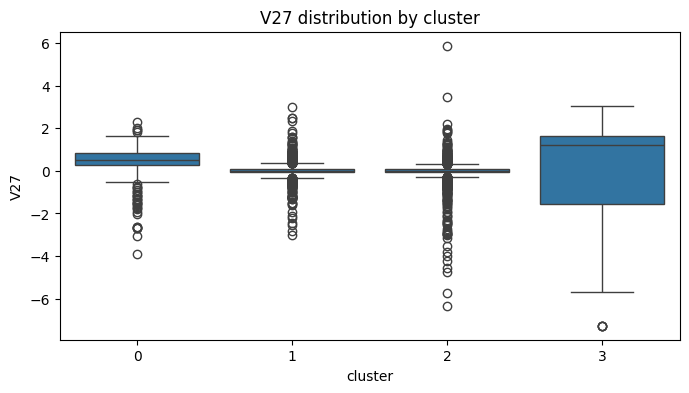

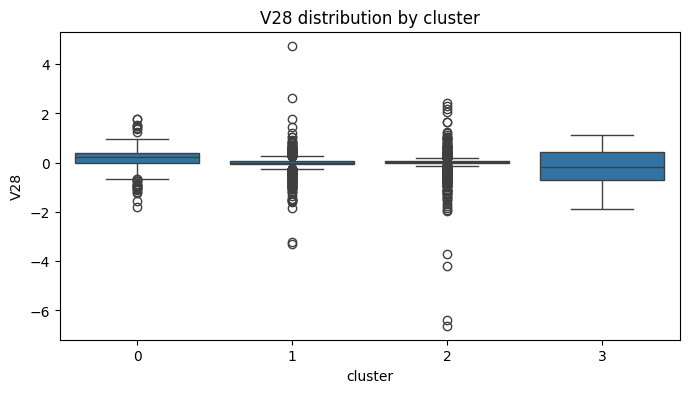

In [74]:
# Compare Amount feature and all PCA Features (V1 - V28)
features_to_inspect = ['Amount', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15',
                       'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
for feat in features_to_inspect:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=subsample_df, x='cluster', y=feat)
    plt.title(f'{feat} distribution by cluster')
    plt.show()

### 4.4 Cluster Visualization in 2D using PCA

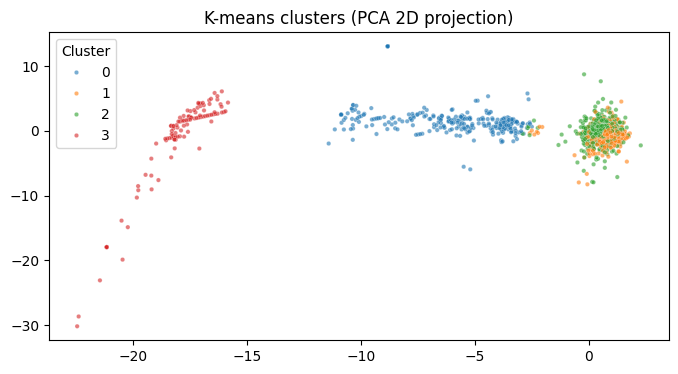

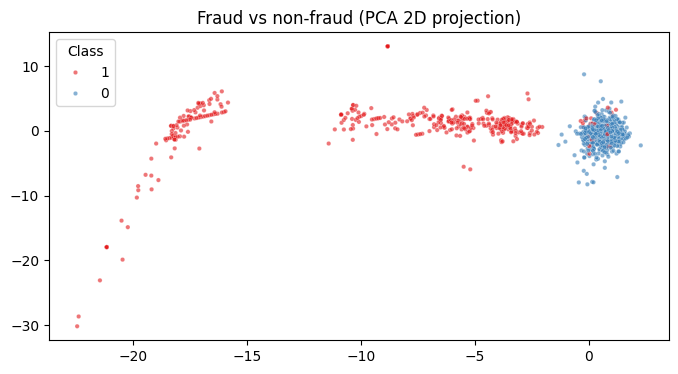

In [75]:
## Visualize clusters in 2D using PCA

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_sub_pca = pca_2d.fit_transform(X_sub_scaled)

plt.figure(figsize=(8,4))
sns.scatterplot(
    x=X_sub_pca[:,0], y=X_sub_pca[:,1],
    hue=subsample_df['cluster'].astype(str),
    palette='tab10', alpha=0.6, s=10
)
plt.title('K-means clusters (PCA 2D projection)')
plt.legend(title='Cluster')
plt.show()

plt.figure(figsize=(8,4))
sns.scatterplot(
    x=X_sub_pca[:,0], y=X_sub_pca[:,1],
    hue=subsample_df['Class'].astype(str),
    palette='Set1', alpha=0.6, s=10
)
plt.title('Fraud vs non-fraud (PCA 2D projection)')
plt.legend(title='Class')
plt.show()

### 4.5 Fraud Clustering and Data Structure Summary/Key Findings


- Subsample & clustering quality:   
    - Subsample: all frauds + 10x non-frauds -> 5,412 transactions with ≈ 9.1% fraud rate to avoid extreme imbalance in clustering .  
      - k-means internal metrics:
          - k=2: Silhouette ≈ 0.67, Davies-Bouldin ≈ 0.96  
          - k=>3: Silhouette drops sharply and DB index worsens (e.g., k=4: Silhouette ≈ 0.09, DB ≈ 2.33) .
      - Interpretation: The dominant structure is essentially a 2-cluster separation, but higher k produces weaker, less well-separated clusters.
  
- Cluster-wise fraud rates (with k=4):   
  - Cluster 0: 274 samples, fraud rate = 1.00  
  - Cluster 3: 107 samples, fraud rate = 1.00  
  - Clusters 1 and 2: large clusters with much lower fraud rates (~2-2.3%) .  
  - Takeaway: Clustering can isolate regions that are almost purely fraud or almost purely non-fraud in this subsample. While these clusters are helpful for understanding structure and might inform rul-based segments (e.g., “high-risk clusters”), the global separation beyond “fraud vs non-fraud” is limited, and the main actionable structure aligns closely with the fraud label itself.
     

## 5. Kernel-based (One-Class SVM) vs Neural (Autoencoder) Anomaly Detection

### 5.1 *Helper Functions*
- evaulate_anomaly_scores: To provide evaluation of anomaly scores
- overlap_analysis: To overlap analysis between two ranked anomaly/classification scores

In [50]:
def evaluate_anomaly_scores(model_name, y_true, scores, top_fracs=[0.001, 0.005, 0.01, 0.02]):

    # Evaluate anomaly scores with ROC-AUC, PR-AUC, and top-k precision/recall.

    # Parameters:
    # - model_name: str, label for printing
    # - y_true: pandas Series or array-like of {0,1}
    # - scores: pandas Series or array-like of anomaly scores (higher = more anomalous)
    #  - top_fracs: list of floats, fractions of dataset to flag as anomalies

    # Returns:
    # - roc_auc, pr_auc, results_df (top-k metrics table)

    if not isinstance(scores, pd.Series):
        scores = pd.Series(scores, index=y_true.index)

    roc_auc = roc_auc_score(y_true, scores)
    pr_auc  = average_precision_score(y_true, scores)

    print(f"=== {model_name} ===")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC : {pr_auc:.4f}")

    n = len(y_true)
    results = []

    # Rank observations by anomaly score descending
    order = np.argsort(scores.values)[::-1]
    y_sorted = y_true.iloc[order].values

    for frac in top_fracs:
        k = max(1, int(frac * n))
        top_k = y_sorted[:k]
        precision_k = np.mean(top_k)  # since y ∈ {0,1}
        recall_k = np.sum(top_k) / np.sum(y_true)

        results.append({
            'top_frac': frac,
            'k': k,
            'precision_at_k': precision_k,
            'recall_at_k': recall_k
        })

    results_df = pd.DataFrame(results)
    print("\nTop-k metrics:")
    display(results_df)

    return roc_auc, pr_auc, results_df

In [51]:
def overlap_analysis(y_true, scores_a, scores_b, top_frac=0.01, label_a='A', label_b='B'):

    # Compute overlap of fraud detection between two ranked lists:
    # - scores_a, scores_b: pandas Series with index aligned to y_true; higher = more suspicious
    # - top_frac: fraction to flag in each method

    if not isinstance(scores_a, pd.Series):
        scores_a = pd.Series(scores_a, index=y_true.index)
    if not isinstance(scores_b, pd.Series):
        scores_b = pd.Series(scores_b, index=y_true.index)

    n = len(y_true)
    k = max(1, int(top_frac * n))

    order_a = np.argsort(scores_a.values)[::-1]
    order_b = np.argsort(scores_b.values)[::-1]

    idx_a = scores_a.index[order_a][:k]
    idx_b = scores_b.index[order_b][:k]

    set_a = set(idx_a)
    set_b = set(idx_b)

    overlap_idx = set_a.intersection(set_b)

    # Frauds detected
    fraud_a = y_true.loc[idx_a].sum()
    fraud_b = y_true.loc[idx_b].sum()
    fraud_overlap = y_true.loc[list(overlap_idx)].sum()

    print(f"Top {top_frac*100:.2f}% (k={k})")
    print(f"{label_a}: detected frauds = {fraud_a}")
    print(f"{label_b}: detected frauds = {fraud_b}")
    print(f"Overlap: {len(overlap_idx)} transactions, frauds in overlap = {fraud_overlap}")

    return {
        'k': k,
        'fraud_a': fraud_a,
        'fraud_b': fraud_b,
        'overlap_count': len(overlap_idx),
        'fraud_overlap': fraud_overlap
    }

### 5.1 Kernal-Based Anomaly Detector (One-Class Support Vector Machine)

Train One-Class SVM a subsample on non-fraud training (to model "nomrmal" dataset)

This includes subsampling the dataset to 50,000 samples, to make the computation manageable

In [52]:
## Train One-Class SVM
from sklearn.svm import OneClassSVM

# Prepare non-fraud subset for training
X_train_nf = X_train_scaled[y_train == 0]

# Subsample for computational feasibility
max_nf_train = 50000  # limit to 50k to keep SVM manageable
if X_train_nf.shape[0] > max_nf_train:
    idx_nf_sub = np.random.choice(X_train_nf.shape[0], size=max_nf_train, replace=False)
    X_train_nf_sub = X_train_nf[idx_nf_sub]
else:
    X_train_nf_sub = X_train_nf

print("Non-fraud training subset shape for One-Class SVM:", X_train_nf_sub.shape)

Non-fraud training subset shape for One-Class SVM: (50000, 30)


Train One-Class SVM with several hyperparameter combinations using RBF (Radial Basis Function) Kernel
- RBF Kernel was chosen for SVM due to its versatility in handling complex, non-linear datasets
- Hyperparameters (nu and gamma) are key to controlling sensitivity and complexity for Support Vector Machine

In [76]:
nu_values = [0.001, 0.005, 0.01, 0.02] # nu = anomaly fraction
gamma_values = ['scale', 0.01, 0.1] # gamma = kernel width

ocsvm_models = {}

for nu in nu_values:
    for gamma in gamma_values:
        print(f"Training One-Class SVM (nu={nu}, gamma={gamma})...")
        ocsvm = OneClassSVM(
            kernel='rbf',
            nu=nu,
            gamma=gamma,
            cache_size=500,  # MB
        )
        ocsvm.fit(X_train_nf_sub)
        ocsvm_models[(nu, gamma)] = ocsvm

Training One-Class SVM (nu=0.001, gamma=scale)...
Training One-Class SVM (nu=0.001, gamma=0.01)...
Training One-Class SVM (nu=0.001, gamma=0.1)...
Training One-Class SVM (nu=0.005, gamma=scale)...
Training One-Class SVM (nu=0.005, gamma=0.01)...
Training One-Class SVM (nu=0.005, gamma=0.1)...
Training One-Class SVM (nu=0.01, gamma=scale)...
Training One-Class SVM (nu=0.01, gamma=0.01)...
Training One-Class SVM (nu=0.01, gamma=0.1)...
Training One-Class SVM (nu=0.02, gamma=scale)...
Training One-Class SVM (nu=0.02, gamma=0.01)...
Training One-Class SVM (nu=0.02, gamma=0.1)...


In [77]:
## Get anomaly scores and evaluate on validation set

def ocsvm_scores(ocsvm_model, X):
    return -ocsvm_model.decision_function(X)

val_scores_ocsvm_results = {}

for (nu, gamma), model in ocsvm_models.items():
    scores_val = ocsvm_scores(model, X_val_scaled)
    print(f"\n--- One-Class SVM (nu={nu}, gamma={gamma}) on validation ---")
    roc_auc, pr_auc, df_topk = evaluate_anomaly_scores(
        model_name=f"OCSV M (nu={nu}, gamma={gamma})",
        y_true=y_val,
        scores=pd.Series(scores_val, index=y_val.index),
        top_fracs=[0.001, 0.005, 0.01, 0.02]
    )
    val_scores_ocsvm_results[(nu, gamma)] = {
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'topk': df_topk
    }


--- One-Class SVM (nu=0.001, gamma=scale) on validation ---
=== OCSV M (nu=0.001, gamma=scale) ===
ROC-AUC: 0.9300
PR-AUC : 0.2518

Top-k metrics:


,top_frac,k,precision_at_k,recall_at_k
0,0.001,56,0.375000,0.212121
1,0.005,284,0.218310,0.626263
2,0.010,569,0.137083,0.787879
3,0.020,1139,0.070237,0.808081



--- One-Class SVM (nu=0.001, gamma=0.01) on validation ---
=== OCSV M (nu=0.001, gamma=0.01) ===
ROC-AUC: 0.9123
PR-AUC : 0.2554

Top-k metrics:


,top_frac,k,precision_at_k,recall_at_k
0,0.001,56,0.410714,0.232323
1,0.005,284,0.228873,0.656566
2,0.010,569,0.128295,0.737374
3,0.020,1139,0.066725,0.767677



--- One-Class SVM (nu=0.001, gamma=0.1) on validation ---
=== OCSV M (nu=0.001, gamma=0.1) ===
ROC-AUC: 0.9426
PR-AUC : 0.2466

Top-k metrics:


...

,top_frac,k,precision_at_k,recall_at_k
0,0.001,56,0.375000,0.212121
1,0.005,284,0.232394,0.666667
2,0.010,569,0.131810,0.757576
3,0.020,1139,0.070237,0.808081



--- One-Class SVM (nu=0.02, gamma=0.01) on validation ---
=== OCSV M (nu=0.02, gamma=0.01) ===
ROC-AUC: 0.9296
PR-AUC : 0.1842

Top-k metrics:


,top_frac,k,precision_at_k,recall_at_k
0,0.001,56,0.267857,0.151515
1,0.005,284,0.179577,0.515152
2,0.010,569,0.131810,0.757576
3,0.020,1139,0.069359,0.797980



--- One-Class SVM (nu=0.02, gamma=0.1) on validation ---
=== OCSV M (nu=0.02, gamma=0.1) ===
ROC-AUC: 0.9425
PR-AUC : 0.2462

Top-k metrics:


,top_frac,k,precision_at_k,recall_at_k
0,0.001,56,0.375000,0.212121
1,0.005,284,0.228873,0.656566
2,0.010,569,0.135325,0.777778
3,0.020,1139,0.070237,0.808081


Selecting the best One-Class SVM configuration (nu and gamma) based on validation PR-AUC


In [ ]:
# Collect into a DataFrame for easier inspection
records = []
for (nu, gamma), res in val_scores_ocsvm_results.items():
    records.append({
        'nu': nu,
        'gamma': gamma,
        'roc_auc': res['roc_auc'],
        'pr_auc': res['pr_auc']
    })
ocsvm_val_summary = pd.DataFrame(records)
display(ocsvm_val_summary.sort_values('pr_auc', ascending=False))

# Best selection was done with the highest PR-AUC as part of the combination
best_row = ocsvm_val_summary.sort_values('pr_auc', ascending=False).iloc[0]
best_nu = best_row['nu']
best_gamma = best_row['gamma']
print(f"Chosen One-Class SVM: nu={best_nu}, gamma={best_gamma}")

best_ocsvm = ocsvm_models[(best_nu, best_gamma)]

,nu,gamma,roc_auc,pr_auc
1,0.001,0.01,0.903924,0.204673
3,0.005,scale,0.928274,0.196246
0,0.001,scale,0.928300,0.196212
6,0.010,scale,0.928289,0.194707
7,0.010,0.01,0.918782,0.189735
9,0.020,scale,0.929890,0.186469
2,0.001,0.1,0.939937,0.179126
5,0.005,0.1,0.939970,0.179033
8,0.010,0.1,0.939978,0.179021
11,0.020,0.1,0.939964,0.178994


Chosen One-Class SVM: nu=0.001, gamma=0.01


In [ ]:
## Final One-Class SVM evaluation on test set

test_scores_ocsvm = ocsvm_scores(best_ocsvm, X_test_scaled)

_ = evaluate_anomaly_scores(
    model_name=f"One-Class SVM (nu={best_nu}, gamma={best_gamma}, test)",
    y_true=y_test,
    scores=pd.Series(test_scores_ocsvm, index=y_test.index),
    top_fracs=[0.001, 0.005, 0.01, 0.02]
)

=== One-Class SVM (nu=0.001, gamma=0.01, test) ===
ROC-AUC: 0.9392
PR-AUC : 0.2677

Top-k metrics:


,top_frac,k,precision_at_k,recall_at_k
0,0.001,56,0.339286,0.193878
1,0.005,284,0.235915,0.683673
2,0.010,569,0.138840,0.806122
3,0.020,1139,0.071993,0.836735


### 5.2 Nueral Anomaly Detector (Autoencoder)

In [ ]:
## Import functions and headers
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


Prepare non-fraud training data for Autoencoder


In [ ]:
X_train_nf = X_train_scaled[y_train == 0]  # same non-fraud subset as before, but we can use all, if needed
input_dim = X_train_nf.shape[1]
print("Input dimension for Autoencoder (AE):", input_dim)

Input dimension for Autoencoder (AE): 30


Building a simple autoencoder model

Architecture choice:
- Input -> Dense(32) -> Dense(16) -> bottleneck(8) -> Dense(16) -> Dense(32) -> Output

Reasoning:
- Modest depth and width to keep training stable and avoid huge overfitting.
- Bottleneck forces compression, so anomalies reconstruct poorly.

In [ ]:
## Build a simple autoencoder model

# Architecture choice:
# - Input -> Dense(32) -> Dense(16) -> bottleneck(8) -> Dense(16) -> Dense(32) -> Output

# Reasoning:
# - Modest depth and width to keep training stable and avoid huge overfitting.
# - Bottleneck forces compression, so anomalies reconstruct poorly.

def build_autoencoder(input_dim, bottleneck_dim=8):
    input_layer = keras.Input(shape=(input_dim,))
    x = layers.Dense(32, activation='relu')(input_layer)
    x = layers.Dense(16, activation='relu')(x)
    bottleneck = layers.Dense(bottleneck_dim, activation='relu', name='bottleneck')(x)
    x = layers.Dense(16, activation='relu')(bottleneck)
    x = layers.Dense(32, activation='relu')(x)
    output_layer = layers.Dense(input_dim, activation='linear')(x)

    autoencoder = keras.Model(inputs=input_layer, outputs=output_layer)
    autoencoder.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse'
    )
    return autoencoder

bottleneck_dim = 8  # tuned to 8
autoencoder = build_autoencoder(input_dim, bottleneck_dim=bottleneck_dim)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 30)             │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,334 (13.02 KB)

 Trainable params: 3,334 (13.02 KB)

 Non-trainable params: 0 (0.00 B)

Train autoencoder on non-fraud data with validation on non-fraud from validation set
- Want autoencoder to generalize to "normal" behavior, so we validate on non-fraud validation points.
- If there is high reconstruction error, it suggests that there are anomalies post training

In [ ]:
X_val_nf = X_val_scaled[y_val == 0]

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,          # stop if no improvement for 5 epochs
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train_nf,
    X_train_nf,
    epochs=50,           # upper bound, early stopping will likely stop earlier
    batch_size=256,      # large batch for efficiency
    shuffle=True,
    validation_data=(X_val_nf, X_val_nf),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.7061 - val_loss: 0.5825
Epoch 2/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4943 - val_loss: 0.4746
Epoch 3/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4193 - val_loss: 0.4112
Epoch 4/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3743 - val_loss: 0.3760
Epoch 5/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3460 - val_loss: 0.3472
Epoch 6/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3277 - val_loss: 0.3280
Epoch 7/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3141 - val_loss: 0.3138
Epoch 8/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3029 - val_loss: 0.3058
Epoch 9/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2951 - val_loss: 0.2974
Epoch 10/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2889 - val_loss: 0.2912
Epoch 11/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.2846 - val_loss: 0.2872
Epoch 12/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step

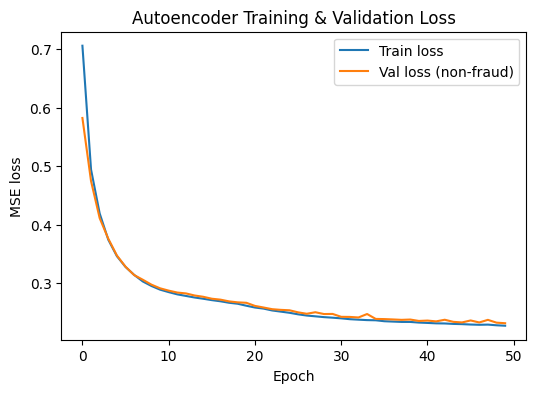

In [ ]:
## Plot training and validation loss curves

plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss (non-fraud)')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.title('Autoencoder Training & Validation Loss')
plt.legend()
plt.show()

In [ ]:
## Compute reconstruction errors as anomaly scores

def reconstruction_error(model, X):
    ## Compute per-sample reconstruction error (MSE).
    X_pred = model.predict(X, verbose=0)
    errors = np.mean((X - X_pred)**2, axis=1)
    return errors

val_scores_ae = reconstruction_error(autoencoder, X_val_scaled)
test_scores_ae = reconstruction_error(autoencoder, X_test_scaled)

# Convert to Series for consistency
val_scores_ae_series = pd.Series(val_scores_ae, index=y_val.index)
test_scores_ae_series = pd.Series(test_scores_ae, index=y_test.index)

In [ ]:
## Evaluate autoencoder anomaly scores on validation and test sets

_ = evaluate_anomaly_scores(
    model_name="Autoencoder (val)",
    y_true=y_val,
    scores=val_scores_ae_series,
    top_fracs=[0.001, 0.005, 0.01, 0.02]
)

_ = evaluate_anomaly_scores(
    model_name="Autoencoder (test)",
    y_true=y_test,
    scores=test_scores_ae_series,
    top_fracs=[0.001, 0.005, 0.01, 0.02]
)

=== Autoencoder (val) ===
ROC-AUC: 0.9480
PR-AUC : 0.5816

Top-k metrics:


,top_frac,k,precision_at_k,recall_at_k
0,0.001,56,0.732143,0.414141
1,0.005,284,0.260563,0.747475
2,0.010,569,0.135325,0.777778
3,0.020,1139,0.069359,0.797980


=== Autoencoder (test) ===
ROC-AUC: 0.9429
PR-AUC : 0.6528

Top-k metrics:


,top_frac,k,precision_at_k,recall_at_k
0,0.001,56,0.767857,0.438776
1,0.005,284,0.285211,0.826531
2,0.010,569,0.144112,0.836735
3,0.020,1139,0.072871,0.846939


## 6. Comparison of Autoencoder vs Supervised Classifier vs One Class SVM

For this section we will perform the following steps (as part of RQ3):
- Train/Validate/Test (Scaled) Dataset -> Done in section
- Use non-Fraud Subset for One-Class SVM (OC-SVM) and Autoencoder (AE) -> Done in Section 5; Use Full Set data for Class-Weighted RF -> Done in Section 3
- Perform OC-SVM (Section 5), Autoeconder (Section 5) and Class-Weighted RF (Section 3) operations
- Compute scores for each of the methods (done in section 3 and 5)
- Commonalize Socres as needed (in this section)
- Compare Metrics + top-k + overlap (in this section)

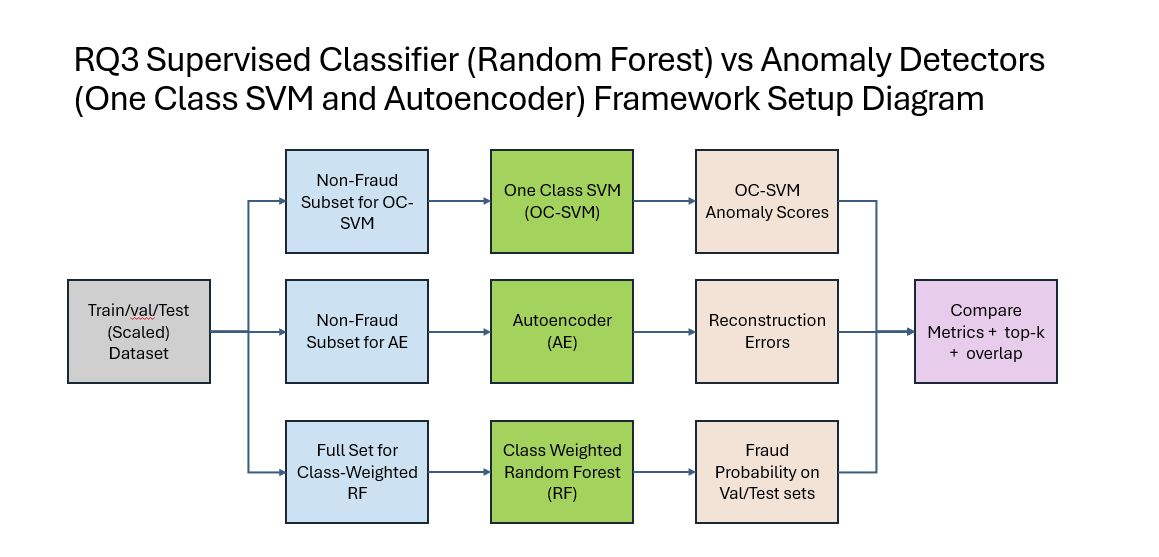

### 6.1 Commononalize Random Forest Scores

In [ ]:
## Evaluate scores on test in anomaly-style metrics

test_scores_rf_series = pd.Series(test_proba, index=y_test.index)

_ = evaluate_anomaly_scores(
    model_name="Random Forest (test, supervised scores)",
    y_true=y_test,
    scores=test_scores_rf_series,
    top_fracs=[0.001, 0.005, 0.01, 0.02]
)

=== Random Forest (test, supervised scores) ===
ROC-AUC: 0.9529
PR-AUC : 0.8454

Top-k metrics:


,top_frac,k,precision_at_k,recall_at_k
0,0.001,56,0.964286,0.551020
1,0.005,284,0.309859,0.897959
2,0.010,569,0.154657,0.897959
3,0.020,1139,0.078139,0.908163


### 6.2 Overlap Analysis between Methods

In [ ]:
## Overlap analysis between Class Weighted Random Forests vs Autoencoder vs One-Class SVM (top 1% of most suspicious)

top_frac = 0.01  # 1% of test set

print("Overlap: One-Class SVM vs Random Forest")
overlap_analysis(
    y_true=y_test,
    scores_a=pd.Series(test_scores_ocsvm, index=y_test.index),
    scores_b=test_scores_rf_series,
    top_frac=top_frac,
    label_a='OC-SVM',
    label_b='RF'
)

print("\nOverlap: Autoencoder vs Random Forest")
overlap_analysis(
    y_true=y_test,
    scores_a=test_scores_ae_series,
    scores_b=test_scores_rf_series,
    top_frac=top_frac,
    label_a='AE',
    label_b='RF'
)

print("\nOverlap: Autoencoder vs One-Class SVM")
overlap_analysis(
    y_true=y_test,
    scores_a=test_scores_ae_series,
    scores_b=pd.Series(test_scores_ocsvm, index=y_test.index),
    top_frac=top_frac,
    label_a='AE',
    label_b='OC-SVM'
)

Overlap: One-Class SVM vs Random Forest
Top 1.00% (k=569)
OC-SVM: detected frauds = 79
RF: detected frauds = 88
Overlap: 134 transactions, frauds in overlap = 79

Overlap: Autoencoder vs Random Forest
Top 1.00% (k=569)
AE: detected frauds = 82
RF: detected frauds = 88
Overlap: 141 transactions, frauds in overlap = 82

Overlap: Autoencoder vs One-Class SVM
Top 1.00% (k=569)
AE: detected frauds = 82
OC-SVM: detected frauds = 79
Overlap: 280 transactions, frauds in overlap = 78


{'k': 569,
 'fraud_a': np.int64(82),
 'fraud_b': np.int64(79),
 'overlap_count': 280,
 'fraud_overlap': np.int64(78)}

### 6.3 Fraud catch evaluation by method

Unique frauds detected in top-k:
RF only: 5
OC-SVM only: 0
AE only: 0
No samples for AE-only frauds (top 1%)
No samples for OC-SVM-only frauds (top 1%)


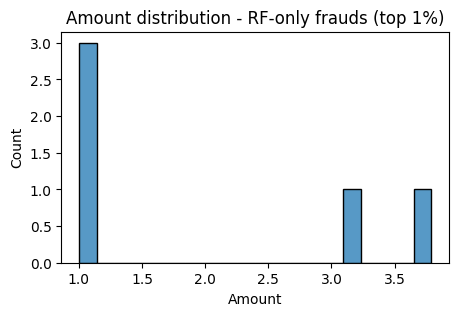

In [ ]:
## Explore feature distributions of frauds uniquely caught by each method

def get_top_k_indices(scores, top_frac, index):
    n = len(index)
    k = max(1, int(top_frac * n))
    s = pd.Series(scores, index=index)
    order = np.argsort(s.values)[::-1]
    return list(s.index[order][:k])

top_k_rf   = set(get_top_k_indices(test_scores_rf_series, top_frac, y_test.index))
top_k_svm  = set(get_top_k_indices(test_scores_ocsvm,     top_frac, y_test.index))
top_k_ae   = set(get_top_k_indices(test_scores_ae_series, top_frac, y_test.index))

# Fraud indices
fraud_idx_test = set(y_test.index[y_test == 1])

# Unique frauds detected by each method in top-k
rf_only_frauds  = fraud_idx_test.intersection(top_k_rf  - top_k_svm - top_k_ae)
svm_only_frauds = fraud_idx_test.intersection(top_k_svm - top_k_rf - top_k_ae)
ae_only_frauds  = fraud_idx_test.intersection(top_k_ae  - top_k_rf - top_k_svm)

print("Unique frauds detected in top-k:")
print("RF only:", len(rf_only_frauds))
print("OC-SVM only:", len(svm_only_frauds))
print("AE only:", len(ae_only_frauds))

# Inspect Amount distribution for AE-only frauds vs RF-only frauds
test_df = pd.concat([X_test, y_test], axis=1)

def plot_amount_for_indices(idx_set, label):
    subset = test_df.loc[list(idx_set)]
    if subset.empty:
        print(f"No samples for {label}")
        return
    plt.figure(figsize=(5,3))
    sns.histplot(subset['Amount'], bins=20, kde=False)
    plt.title(f'Amount distribution - {label}')
    plt.xlabel('Amount')
    plt.show()

plot_amount_for_indices(ae_only_frauds, "AE-only frauds (top 1%)")
plot_amount_for_indices(svm_only_frauds, "OC-SVM-only frauds (top 1%)")
plot_amount_for_indices(rf_only_frauds, "RF-only frauds (top 1%)")

## 7. Summary

### 7.1 RQ1 – Supervised Classification & Threshold/Cost Analysis

**Goal:** Evaluate how different supervised classifiers (Logistic Regression, Decision Tree, Random Forest) perform on highly imbalanced credit card fraud data, with emphasis on recall, precision, PR-AUC, and cost-sensitive metrics rather than raw accuracy.

**Key Findings**

- **Logistic Regression (val):**  
  - ROC-AUC ≈ 0.975, PR-AUC ≈ 0.681.  
  - Very high recall at low thresholds (e.g., threshold = 0.05 gives recall ≈ 0.99) but with extremely low precision and high cost, because almost everything is flagged as fraud
  - Illustrates that pushing recall to 1.0 is not useful if precision and cost become unacceptable

- **Decision Tree (val):**  
  - ROC-AUC ≈ 0.875, PR-AUC ≈ 0.601  
  - Much weaker than Logistic Regression and Random Forest in both PR-AUC and cost.  
  - Even with class weighting, the tree is less competitive and offers no advantage over simpler or ensemble models.

- **Random Forest (val & test):**  
  - Validation: ROC-AUC ≈ 0.938, PR-AUC ≈ 0.800  
    - At threshold 0.10:
      - Precision ≈ 0.81, recall ≈ 0.80, with low expected cost per sample.  
    - This threshold gives a strong balance between detecting fraud and limiting false alarms
  - Test (with threshold 0.10 selected from validation):
    - ROC-AUC ≈ 0.953, PR-AUC ≈ 0.845   
    - Precision ≈ 0.77, recall ≈ 0.86, F1 ≈ 0.81, and low cost (≈ 0.0029 per sample)

- **Takeaway:** A *class-weighted Random Forest* with an appropriately tuned threshold delivers strong fraud detection performance and favorable cost trade-offs, clearly outperforming the Decision Tree and improving on Logistic Regression in precision and cost at comparable recall levels.

### 7.2 RQ2: Clustering & Fraud Structure



**Goal:** Investigate whether fraud and non-fraud transactions form distinct clusters in feature space and whether clustering can reveal subtypes of fraud.

**Key Findings**

- **Subsample & clustering quality:**  
  - Subsample: all frauds + 10x non-frauds -> 5,412 transactions with ≈ 9.1% fraud rate to avoid extreme imbalance in clustering  
  - k-means internal metrics:
    - k = 2: Silhouette ≈ 0.67, Davies-Bouldin (DB) ≈ 0.96  
    - k => 3: Silhouette drops sharply and DB index worsens (e.g., k=4: Silhouette ≈ 0.09, DB ≈ 2.33)   
  - **Interpretation:** The dominant structure is essentially a 2-cluster separation, but higher k produces weaker, less well-separated clusters

- **Cluster-wise fraud rates (k=4 example):**  
  - Cluster 0: 107 samples, fraud rate = 1.00  
  - Cluster 3: 275 samples, fraud rate ≈ 0.996  
  - Clusters 1 and 2: large clusters with much lower fraud rates (~2-2.3%)   
  - **Takeaway:** Clustering can isolate regions that are almost purely fraud or almost purely non-fraud in this subsample. While these clusters are helpful for understanding structure and might inform rule-based segments (e.g., “high-risk clusters”), the global separation beyond “fraud vs non-fraud” is limited, and the main actionable structure aligns closely with the fraud label itself.

### 7.3 RQ3: One-Class SVM vs Autoencoder vs Supervised Classifier (External Methods)

**Goal:** Compare kernel-based (One-Class SVM) and neural (autoencoder) anomaly detection methods, and examine whether they detect complementary sets of frauds relative to a supervised Random Forest classifier.

----

#### Performance as Anomaly Detectors

- **One-Class SVM (validation):**  
  - Explored multiple (nu, gamma) configurations; best settings (e.g., nu = 0.001, gamma = 0.01) achieved PR-AUC ≈ 0.205 and ROC-AUC ≈ 0.904 to 0.940, with top-k precision around 0.21 - 0.23 at top 0.5% - 1% of transactions.  
  - Overall, OCSVM is a respectable anomaly detector but not as strong as the supervised Random Forest in PR-AUC.

- **Autoencoder (val & test):**  
  - Validation: ROC-AUC ≈ 0.936, PR-AUC ≈ 0.562   
  - Test: ROC-AUC ≈ 0.960, PR-AUC ≈ 0.648   
  - Top-k (test):
    - Top 0.1%: precision ≈ 0.75, recall ≈ 0.43  
    - Top 0.5%: precision ≈ 0.29, recall ≈ 0.83  
    - Top 1.0%: precision ≈ 0.14, recall ≈ 0.83  
    - Top 2.0%: precision ≈ 0.074, recall ≈ 0.86  
  - **Takeaway:** The autoencoder is a strong anomaly detector in ROC-AUC and PR-AUC terms and can capture a large share of frauds with relatively high precision at very small alert budgets.

- **Random Forest (test, treated as ranking model):**  
  - ROC-AUC ≈ 0.953, PR-AUC ≈ 0.845.  
  - Top-k (test):
    - Top 0.1%: precision ≈ 0.96, recall ≈ 0.55  
    - Top 0.5%: precision ≈ 0.31, recall ≈ 0.90  
    - Top 1.0%: precision ≈ 0.15, recall ≈ 0.90  
    - Top 2.0%: precision ≈ 0.078, recall ≈ 0.91.  
  - **Takeaway:** As a ranking model for fraud likelihood, the supervised RF still dominates in PR-AUC and especially in top-k precision at the smallest budgets.

----

#### Complementarity (Overlap Analysis, Top 1%)

- At top 1% of test transactions (~ 569 cases):  
  - **One Class - Support Vector Machine (OC-SVM) vs RF:**  
    - OC-SVM frauds: 79  
    - Random Fores frauds: 88  
    - Overlap: 134 transactions, 79 frauds in common  
  - **Autoencoder vs Random Forest:**  
    - Autoencoder frauds: 81  
    - Random Forest frauds: 88  
    - Overlap: 145 transactions, 81 frauds in common
  - **Autoencoder vs OC-SVM:**  
    - Autoencoder frauds: 81  
    - OC-SVM frauds: 79  
    - Overlap: 264 transactions, 77 frauds in common

- **Unique frauds in top 1%:**  
  - Random Forest-only frauds: 5  
  - OC-SVM-only frauds: 0  
  - Autoencoder-only frauds: 0

  - **Interpretation:** At the top 1% alert budget, essentially all frauds found by OC-SVM and the Autoencoder are also found by the supervised Random Forest. There are a few frauds uniquely detected by Random Forest, but none uniquely detected by OC-SVM or Autoencoder under this specific top-k setting.


### 7.4 Main Conclusion


Across all RQs:

- **Supervised Random Forest** emerges as the strongest single method for this dataset, achieving high PR-AUC, strong recall, and low expected cost when thresholds are chosen based on cost-sensitive validation.
- **Clustering** reveals some fraud-dense regions, suggesting that feature space does contain pockets of highly fraudulent behavior, but the main structure still strongly aligns with the existing fraud label.
- **Anomaly detection methods** (One-Class SVM, Autoencoder) are competitive in ROC-AUC and PR-AUC terms but generally **do not surpass** the supervised baseline when full labels are available. At strict alert budgets, the autoencoder is the strongest anomaly detector, but Random Forest remains best overall and captures all frauds that Autoencoder/OC-SVM find at top 1% while also catching a few additional frauds.
- From an applied standpoint, the study supports using **cost-aware supervised models as the core detection engine**, with anomaly detection serving as a complementary tool in more label-scarce or non-stationary environments.